In [ ]:
from typing import Annotated
from typing_extensions import TypedDict

from langchain_core.messages import AnyMessage
from langgraph.graph.message import add_messages

from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition

from langchain.tools import tool
from langchain.chat_models import init_chat_model

from langchain_community.tools.tavily_search import TavilySearchResults
from typing import List,Annotated
import os
from pydantic import BaseModel

from langchain_community.vectorstores import FAISS
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain.chat_models import init_chat_model
from langchain_community.document_loaders import WebBaseLoader
from langchain_classic.schema import Document

from langgraph.graph import StateGraph,START,END

C:\Users\mrraj\AppData\Local\Temp\ipykernel_5980\1402860925.py:13: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools.tavily_search import TavilySearchResults
USER_AGENT environment variable not set, consider setting it to identify your requests.


In [2]:
docs = WebBaseLoader("https://en.wikipedia.org/wiki/A._P._J._Abdul_Kalam#Career_as_a_scientist").load()
splitter = RecursiveCharacterTextSplitter(
    chunk_size = 500,
    chunk_overlap = 50
)
chunk = splitter.split_documents(docs)
embedding = HuggingFaceEmbeddings()
vectorestore = FAISS.from_documents(chunk,embedding)
retriever = vectorestore.as_retriever()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

In [3]:
def retriever_tool_func(query:str)->str:
    print("using rag retriever tool")
    docs = retriever.invoke(query)
    return "\n".join([doc.page_content for doc in docs])

In [9]:
from langchain_core.tools import Tool

rag_retriever_tool = Tool(
    name="RAGretriever",
    description="Use this tool to fetch relevant documents.",
    func=retriever_tool_func
)

In [10]:
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper

wikki_tool = WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper())


In [11]:
from dotenv import load_dotenv
load_dotenv()
import os
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
llm = init_chat_model(
    model="openai/gpt-oss-120b",
    model_provider="groq"
)
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.5.1', 'langchain': '1.3.14'}}, output_version=None, profile={'name': 'GPT OSS 120B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000002388AD20190>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000002388AD20B90>, model_name='openai/gpt-oss-120b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

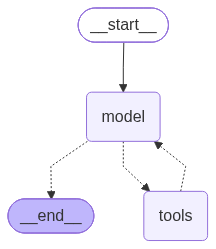

In [14]:
from langchain.agents import create_agent   
tools = [rag_retriever_tool,wikki_tool]
agent = create_agent(
    model=llm,
    tools=tools
)
agent

In [15]:
from langchain_core.messages import BaseMessage
from typing import Sequence
class AgentState(TypedDict):
    message: Annotated[Sequence[BaseMessage],add_messages]

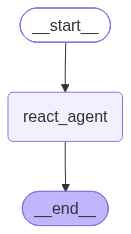

In [18]:
builder = StateGraph(AgentState)

builder.add_node("react_agent",agent)
builder.set_entry_point("react_agent")
builder.add_edge("react_agent",END)

graph = builder.compile()
graph

In [22]:
from langchain_core.messages import HumanMessage
result = agent.invoke({
    "messages": [
        HumanMessage(content="Who is A. P. J. Abdul Kalam?")
    ]
})

print(result["messages"][-1].content)

**A. P. J. Abdul Kalam (15 October 1931 – 27 July 2015)**  

- **Early life & education** – Born in Rameswaram, Tamil Nadu, into a modest Muslim family. He studied physics at St. Joseph’s College, Tiruchirappalli, and later earned a degree in aerospace engineering from the Madras Institute of Technology.  

- **Scientific career** – Spent four decades as a scientist and science administrator, primarily with India’s Defence Research and Development Organisation (DRDO) and Indian Space Research Organisation (ISRO). He played a central role in:  
  - Developing India’s ballistic‑missile and launch‑vehicle programs (Saturn, Agni, Prithvi), earning the nickname **“Missile Man of India.”**  
  - Contributing to the civilian space programme (SLV‑III, Rohini satellites).  
  - Providing technical and organisational leadership for the 1998 Pokhran‑II nuclear tests.  

- **Presidency (2002‑2007)** – Elected the 11th President of India with support from both the BJP and the Congress. Known as the